<a href="https://colab.research.google.com/github/r-okotie179/projectTantalus/blob/main/charity-idea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- have display of students and clubs graphically on a map; having a clear distinction

- note next steps

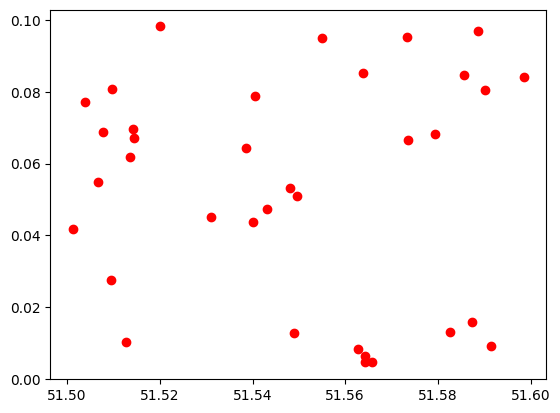

In [80]:
import pandas as pd
import random as rand
import numpy as np
import matplotlib.pyplot as plt

# graph G will be bipartite in form (V, E), V = the union of students (U) and clubs (W)
## defining the clubs, W
def clubs(n):
    '''
    This will have attributes: ID, topics (an issue for later since there could be overlapping topics, what is an important topic, etc), max capacity, cost (per term?), position (latitutde and longitude)
    '''
    W = []
    topics = ["maths tutoring", "extension maths", "admissions preparation", "extension physics", "linguistics", "coding club", "finance society", "book club"] # a critique of this is its vagueness and what it is actually targeting; that needs to be considered in such a model
    # also, wrt to topics, they need to be grouped into certain themes, which could be a separate issues
    max_cap = np.arange(5, 45, 5).tolist() # so that each dtype would be an int
    cost_options = [0,0,0,0,0,5,5,5,5,10,10,10,50,150,150,250]
    for i in range(n):
        W_subset = []
        ID = i
        topic = rand.choice(topics)
        max_capacity = rand.choice(max_cap)
        cost = rand.choice(cost_options)
        position = (rand.uniform(51.5, 51.6), rand.uniform(0.0, 0.1))
        W.append((ID, topic, max_capacity, cost, position))
    return W # a list of length n
clubs = clubs(35)
#print(W) # list of the synthetic data
df_clubs = pd.DataFrame(clubs, columns=['Club-ID', 'Topic', 'Capacity', 'Cost', 'Position']) # made a pandass dataframe
pos = df_clubs['Position'].to_numpy()
x,y = zip(*pos)
plt.scatter(np.array(x), np.array(y), color='red')

### Information about student nodes

`location` -- same as above

`topic` -- topics that they are interested, random selection of a random number of interests

`interest-weighting` -- random number between 1 and 10 for the length of  list of interests

`budget-limit` -- overall thing, might use knapsack algorithm for choosing optimal placings but this would have to consider time constraints also... Would be cool to return to 6.002 when I have a laptop again for this

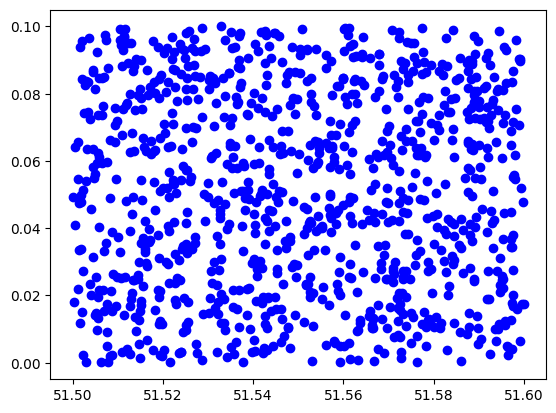

In [74]:
def students(n):
    '''
    This will include the components for the students to use as inputs
    '''
    U = [] # both W and U are subsets of the set of nodes, V
    topics = ["maths tutoring", "extension maths", "admissions preparation", "extension physics", "linguistics", "coding club", "finance society", "book club"] # a critique of this is its vagueness and what it is actually targeting; that needs to be considered in such a model
    for i in range(n): # for each student intstance
        U_subset = []
        ID = i
        topic_no = rand.randint(1,5) # arbitrary maximum
        topic_set = list(set([rand.choice(topics) for i in range(topic_no)])) # simple logic that allows duplicates; they will be reduced in later filtering so the number will unlikely be 5
        interest_weighting = [rand.randint(4,10) for i in range(topic_no)] # minimum is arbitrary; why pick a choice it is a 2 tho
        budget_limit = np.floor(np.random.exponential(scale=10, size=1)).astype(int) # as integer in case of down stream issues, having a consistent data type would reduce that (prob)
        position = (rand.uniform(51.5, 51.6), rand.uniform(0.0, 0.1))

        U.append((ID, topic_set, interest_weighting, budget_limit, position))
    return U

students = students(1000)
df_students = pd.DataFrame(students, columns=['Student-ID', 'Topics-Set', 'Interest-Weighting', 'Budget-Limit', 'Position'])
pos = df_students['Position'].to_numpy()
a,b = zip(*pos)
plt.scatter(np.array(a), np.array(b), color='blue')

- add edges
- consider how topics could be meaningfully grouped into themes and what role LLMs could have in this (as if I were to do a survey, I would have people describe their interests and that description must be vectorised)... I would like to use a smaller in-house model (like 10B parameters) just as practice in case I would need to do this later

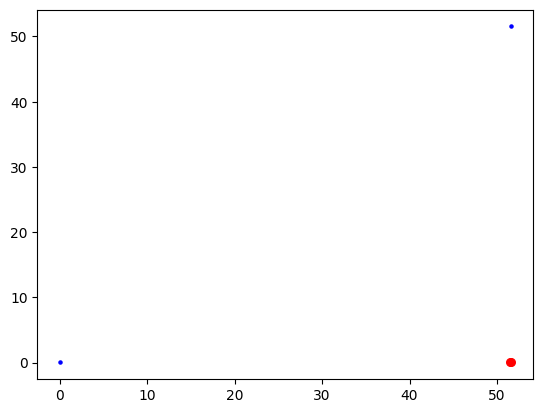

In [73]:
plt.scatter(x,y,color='r',s=30)
plt.scatter(a,b,color='b',s=5)

Below will be the logic for the edges connecting the students to clubs.

Visually, not much will be extracted from that graph, yet I would like some way of this stored data form of:

$$G = (V,E)$$\
$$W \cup U \subseteq {V}$$

After this, I could explore different forms of representation.

In [56]:
def weighting(dist, cost):
  # I need some way of including the strength of intterest
  # the best way would be for comparisons between the student's different clubs in different topics, iif there is a restricted amount of time that they can attend clubs (e.g. only Saturdays)
  # therefore, the interest-weighting aspect is currently not that useful (but another note for future)

  # simple, balanced and normalised weighting
  weight = (np.array(dist) * .5) + (np.array(cost) * 0.5)
  return weight # hopefully outputting a list

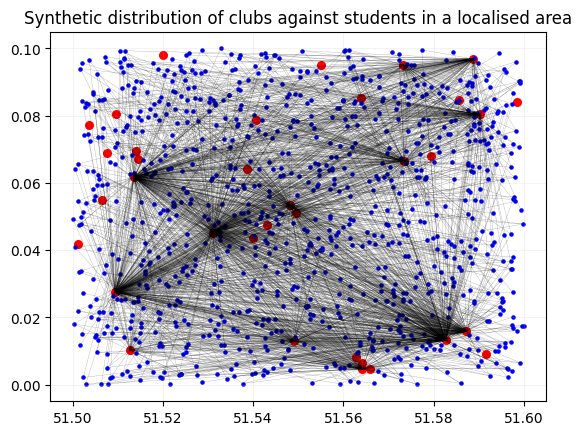

In [84]:
edge_list = []

for i in range(len(df_students)):
  student_i = df_students.loc[i]
  for topic in student_i["Topics-Set"]:
    potential_clubs = df_clubs[df_clubs['Topic'].apply(lambda x: topic in x)]
    club_position_array = np.array(potential_clubs["Position"].tolist()) # needed in list form otherwise a tuple would subtract from a list, which caused an error
    n = len(club_position_array)
    k = student_i["Position"]
    q = np.tile((k), (n,1)) # x carries the position coordinates, whilst n is an integer number
    # now I am calculating the distance between the places
    dist_matrix = club_position_array - q
    club_dist = np.linalg.norm(dist_matrix, axis=1) # for every row it finds the magnitude, better than another for loop
    # I am not sure how to include the strenght of interest into this model now...
    club_cost = np.array(potential_clubs["Cost"].tolist())
    weight = weighting(club_dist, club_cost)
    lowest_weight_index = np.argmin(weight)
    output_club = potential_clubs.iloc[lowest_weight_index]
    #print(output_club)

    # plotting these edges together
    abba = k
    beta = output_club["Position"]
    xx = [abba[0], beta[0]]
    yy = [abba[1], beta[1]]
    plt.plot(xx,yy, lw=.15, color='black', alpha=0.55)

    # storing these edges with specific indexing of (i,j)
    # have the listed quality in this form: [(i,j), weight]
    edge = [[student_i["Student-ID"], output_club["Club-ID"]], weight[lowest_weight_index]]

    edge_list.append(edge)

df_edges = pd.DataFrame(edge_list, columns=["ID", "Weight"])

plt.scatter(x,y,color='r',s=30)
plt.scatter(a,b,color='b',s=5)
plt.grid(alpha=.15)
plt.title("Synthetic distribution of clubs against students in a localised area")
plt.show()

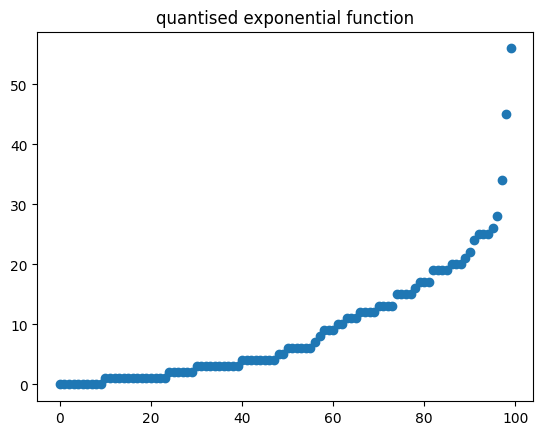

In [ ]:
# this is the distribution used for the cost allocation; most people are around 10 pounds but a few can splurg a little more. I took the floor of the real results
values = np.random.exponential(scale=10, size=100)
x = [i for i in range(len(values))]
#print(x)
values = np.floor(sorted(values))
plt.scatter(x, values)
plt.title("quantised exponential function")
plt.show()
#print(values)